# Week 3 Notebook 2: The first ten minutes with any dataset

**CSC: Data Analytics, Data Mining and Machine Learning**

Every dataset you meet gets the same opening routine. Before modelling or answering a research question, first learn what you actually have.

### Today’s routine
**Size -> rows -> column types -> missing values -> duplicates -> numerical summaries -> distributions -> relationships**

The examples use the Palmer Penguins dataset because it is small, real, and contains common data-quality issues.

## Setup

In [26]:
# pandas: tables and data cleaning; numpy: numerical operations.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display and chart defaults for the rest of the notebook.
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

## Load the data

This notebook uses the **Palmer Penguins** dataset: 344 penguins measured at Palmer Station, Antarctica. It is small, real, and messy in all the usual ways.

Your group's data may not be a CSV file. Pandas can read several common table formats. Choose the reader that matches the file you have:

| File type | Pandas reader |
| --- | --- |
| CSV | `pd.read_csv(...)` |
| TSV or other separated text | `pd.read_csv(..., sep="\t")` |
| Excel | `pd.read_excel(...)` |
| JSON | `pd.read_json(...)` |
| Parquet | `pd.read_parquet(...)` |

Run the penguins example first. Then replace `file_path` and uncomment one alternative reader for your own data. Excel and Parquet files may need an additional package installed in your Python environment.

In [27]:
# Load the file into a pandas DataFrame called df.
file_path = "../data/dndi_compounds-IC50.csv"
df = pd.read_csv(file_path, delimiter="\t")

# For another file, replace file_path and use the matching reader:
# df = pd.read_csv("../data/your_file.tsv", sep="\t")
# df = pd.read_excel("../data/your_file.xlsx")
# df = pd.read_json("../data/your_file.json")
# df = pd.read_parquet("../data/your_file.parquet")

# Preview the first five rows to check that the file loaded as expected.
df.head()

,chembl_id,pref_name,smiles,molecular_weight,logp,hba,hbd,psa,rtb,ro5_violations,aromatic_rings,heavy_atoms,pf_ec50_uM,tb_ic50_uM,tc_ic50_uM,tbrucei_ic50_uM,ld_ic50_uM,cp_ec50_uM,tg_ec50_uM,hepg2_cc50_uM,si_pf,si_tb,si_tc,si_tbrucei,si_ld,si_cp,si_tg
0,CHEMBL516073,NaN,O=[N+]([O-])c1cc2n(n1)CC(OCc1ccc(OC(F)(F)F)cc1...,359.26,2.67,7.0,0.0,88.65,5.0,0.0,2.0,25.0,NaN,NaN,8.2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEMBL3104530,NaN,O=C(c1ccccc1)N1CCC(N(c2ccc(C(F)(F)F)cc2)c2cccn...,425.45,5.54,3.0,0.0,36.44,4.0,1.0,3.0,31.0,NaN,NaN,0.0077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHEMBL4084773,NaN,O=[N+]([O-])c1cn2c(n1)OCC(OCc1ccc(OC(F)(F)F)cc...,373.29,3.06,7.0,0.0,88.65,5.0,0.0,2.0,26.0,NaN,NaN,4.2000,NaN,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHEMBL3104477,NaN,CS(=O)(=O)c1ccc(N2CCC(N(c3ccc(Cl)cc3)c3cccnc3)...,441.98,4.95,5.0,0.0,53.51,5.0,0.0,3.0,30.0,NaN,NaN,0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHEMBL3104536,NaN,FC(F)(F)c1ccc(N2CCC(N(c3ccc(C(F)(F)F)cc3)c3ccc...,465.44,6.93,3.0,0.0,19.37,4.0,1.0,3.0,33.0,NaN,NaN,0.0179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Move 1: How big is it?

Start with the number of **rows and columns**. If the size surprises you, stop and find out why.

In [28]:
# shape returns (number_of_rows, number_of_columns).
print("rows, columns:", df.shape)

rows, columns: (190, 27)


## Move 2: What does a row look like?

Look at a few rows. This helps you understand what one observation represents and whether the values look sensible.

In [29]:
# head() shows the first five rows of the table.
df.head()

,chembl_id,pref_name,smiles,molecular_weight,logp,hba,hbd,psa,rtb,ro5_violations,aromatic_rings,heavy_atoms,pf_ec50_uM,tb_ic50_uM,tc_ic50_uM,tbrucei_ic50_uM,ld_ic50_uM,cp_ec50_uM,tg_ec50_uM,hepg2_cc50_uM,si_pf,si_tb,si_tc,si_tbrucei,si_ld,si_cp,si_tg
0,CHEMBL516073,NaN,O=[N+]([O-])c1cc2n(n1)CC(OCc1ccc(OC(F)(F)F)cc1...,359.26,2.67,7.0,0.0,88.65,5.0,0.0,2.0,25.0,NaN,NaN,8.2000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CHEMBL3104530,NaN,O=C(c1ccccc1)N1CCC(N(c2ccc(C(F)(F)F)cc2)c2cccn...,425.45,5.54,3.0,0.0,36.44,4.0,1.0,3.0,31.0,NaN,NaN,0.0077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CHEMBL4084773,NaN,O=[N+]([O-])c1cn2c(n1)OCC(OCc1ccc(OC(F)(F)F)cc...,373.29,3.06,7.0,0.0,88.65,5.0,0.0,2.0,26.0,NaN,NaN,4.2000,NaN,0.63,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CHEMBL3104477,NaN,CS(=O)(=O)c1ccc(N2CCC(N(c3ccc(Cl)cc3)c3cccnc3)...,441.98,4.95,5.0,0.0,53.51,5.0,0.0,3.0,30.0,NaN,NaN,0.0021,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CHEMBL3104536,NaN,FC(F)(F)c1ccc(N2CCC(N(c3ccc(C(F)(F)F)cc3)c3ccc...,465.44,6.93,3.0,0.0,19.37,4.0,1.0,3.0,33.0,NaN,NaN,0.0179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Move 3: What type is each column?

The single most common data bug: a number stored as text. Use `.info()` to check the data types and whether columns contain missing values.

In [30]:
# info() shows column names, data types, and non-missing value counts.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 190 entries, 0 to 189
Data columns (total 27 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   chembl_id         190 non-null    str    
 1   pref_name         5 non-null      str    
 2   smiles            189 non-null    str    
 3   molecular_weight  190 non-null    float64
 4   logp              182 non-null    float64
 5   hba               182 non-null    float64
 6   hbd               182 non-null    float64
 7   psa               182 non-null    float64
 8   rtb               182 non-null    float64
 9   ro5_violations    182 non-null    float64
 10  aromatic_rings    182 non-null    float64
 11  heavy_atoms       182 non-null    float64
 12  pf_ec50_uM        0 non-null      float64
 13  tb_ic50_uM        4 non-null      float64
 14  tc_ic50_uM        172 non-null    float64
 15  tbrucei_ic50_uM   34 non-null     float64
 16  ld_ic50_uM        53 non-null     float64
 17  cp_ec50_

## Move 4: What is missing?

Counts tell you how much is missing; percentages make it easier to compare columns of different sizes.

Missing data is not automatically an error. First find out **where it is missing and why** before deciding what to do with it.

In [31]:
# Count missing cells in each column.
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})

# Sort so the columns needing the most attention appear first.
missing.sort_values("n_missing", ascending=False)

,n_missing,pct_missing
si_tg,190,100.0
pf_ec50_uM,190,100.0
si_cp,190,100.0
si_pf,190,100.0
tg_ec50_uM,190,100.0
cp_ec50_uM,189,99.5
si_ld,188,98.9
si_tbrucei,188,98.9
si_tc,188,98.9
si_tb,188,98.9


### A question worth asking

Are the missing values scattered through the dataset, or do they occur in particular groups or parts of the file? A pattern in missingness can tell you something about how the data were collected.

---
## Move 5: Duplicates

Exact duplicate rows can indicate a data-processing problem. Check them before analysing the data.

In [32]:
# duplicated() marks rows that are exact copies of an earlier row.
# sum() counts how many duplicate rows were found.
print("exact duplicate rows:", df.duplicated().sum())

exact duplicate rows: 0


---
## Move 6: Summarise the numbers

`.describe()` gives count, mean, standard deviation, minimum, quartiles and maximum for numeric columns.

**Look at the minimum and maximum first.** They can reveal impossible or suspicious values before the average hides them.

In [33]:
# describe() calculates common summaries for numeric columns.
# Transpose so each variable appears as a row, which is easier to read.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
molecular_weight,190.0,418.804368,68.119472,322.0900,374.330000,418.36000,452.125000,924.0900
logp,182.0,3.987747,1.712624,-8.8600,2.970000,3.85000,5.230000,7.0100
hba,182.0,6.010989,2.264277,3.0000,4.000000,7.00000,7.000000,19.0000
hbd,182.0,0.269231,1.353954,0.0000,0.000000,0.00000,0.000000,13.0000
psa,182.0,75.676923,41.208487,19.3700,43.160000,88.65000,101.540000,347.3200
rtb,182.0,4.934066,1.575378,3.0000,4.000000,5.00000,6.000000,20.0000
ro5_violations,182.0,0.335165,0.558980,0.0000,0.000000,0.00000,1.000000,3.0000
aromatic_rings,182.0,2.637363,0.576069,0.0000,2.000000,3.00000,3.000000,3.0000
heavy_atoms,182.0,29.675824,4.096808,23.0000,27.000000,30.00000,32.000000,65.0000
pf_ec50_uM,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Move 7: Look at the distributions

Now connect this notebook to the previous one: use histograms to see the shape of every numeric variable.

Look for:
- skew
- multiple peaks
- gaps
- suspicious spikes
- values that look impossible

You do not need to interpret every detail yet. The goal is to notice what deserves a closer look.

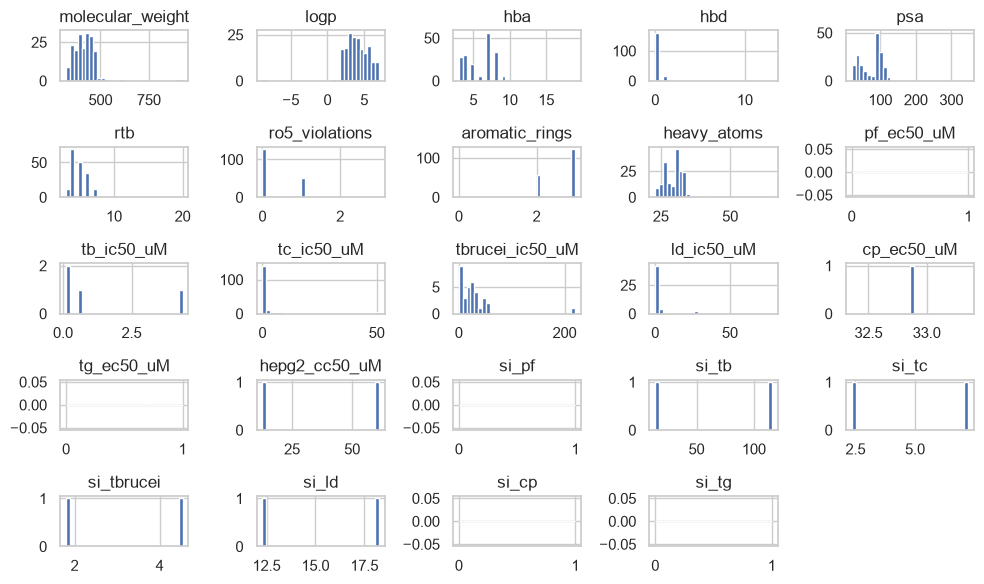

In [34]:
# Select numeric columns and draw one histogram for each.
df.select_dtypes("number").hist(figsize=(10, 6), bins=30, edgecolor="white")
plt.tight_layout()
plt.show()

### One thing to notice

Look at `bill_depth_mm`. It does not look like one simple hump. A distribution can contain multiple groups mixed together, which is one reason that **grouping variables matter**.

---
## Move 8: How do the numbers relate?

A correlation matrix is a fast first pass for numeric variables. In this notebook, pandas uses **Pearson correlation** by default. Pearson correlation measures the strength and direction of a **linear relationship**: whether larger values of one variable tend to occur with larger or smaller values of another variable in a roughly straight-line pattern.

Pearson correlation ranges from `-1` to `1`:

- `1` means a perfect positive linear relationship;
- `-1` means a perfect negative linear relationship; and
- `0` means no linear relationship.

A value near `0` does not prove that there is no relationship. A curved relationship can have a small Pearson correlation. Treat this matrix as a screening tool, then inspect a scatter plot.

Other correlation measures answer slightly different questions. **Spearman correlation** compares the ranks of values and is useful for a consistently increasing or decreasing relationship that is not straight. **Kendall correlation** also uses ranks and is often useful with smaller datasets or many tied values.

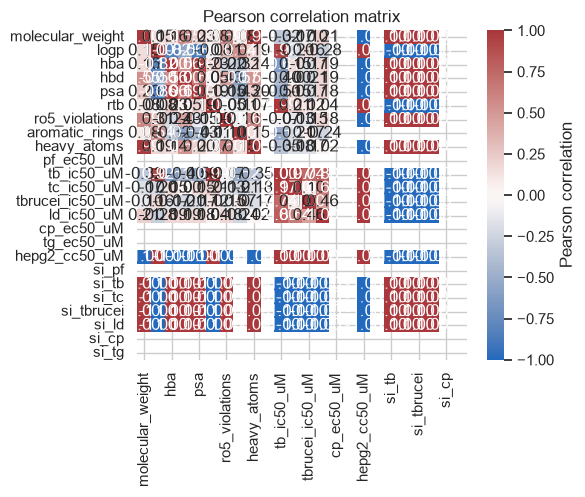

In [35]:
# Select numeric columns and calculate Pearson correlations.
# Pearson is pandas' default method and measures linear relationships.
numeric_data = df.select_dtypes("number")
corr = numeric_data.corr(method="pearson")

# A heatmap makes positive and negative relationships easier to scan.
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

## Check your understanding

Use the outputs above to answer these questions about the penguins dataset. Choose or calculate the answers in the next cell.

- How many rows are in the dataset?
- How many columns are in the dataset?
- Which column has the most missing values?
- How many exact duplicate rows are there?
- Which columns contain numeric measurements?

The final cell loads the external checker from the `tests/` folder and tells you whether your answers are correct.

In [36]:
# Replace each None with your answer.
number_of_rows = 344
number_of_columns = 7
column_with_most_missing = "sex"
duplicate_rows = 0
numeric_columns = [
            "bill_length_mm",
            "bill_depth_mm",
            "flipper_length_mm",
            "body_mass_g",
        ]

print(number_of_rows, number_of_columns)
print(column_with_most_missing, duplicate_rows)
print(numeric_columns)

344 7
sex 0
['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


Run the next cell after filling in your answers. It imports the external test from `tests/` and reports the result without showing the expected answers.

In [37]:
from pathlib import Path
import sys
import importlib

project_root = Path.cwd()
if not (project_root / "tests").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import tests.test_first_look as first_look_tests
importlib.reload(first_look_tests)

check_passed = first_look_tests.check_first_look(globals())
print("Passed" if check_passed else "Not passed yet")

Dataset inspection checks passed!
Passed


---
## Your turn

Take a few minutes to inspect this dataset. Write three short observations:

1. **One thing that surprised you**
2. **One thing that looks potentially wrong or worth checking**
3. **One question you would investigate next**

The aim is not to “solve” the dataset. Good exploratory analysis produces better questions.

In [38]:
# Your three sentences here (as a comment or a markdown cell: your choice)

*One thing that suprised me* - how long their flippers can get (how large the gap is between the smallest and largest flipper)

*One thing that looks potentially wrong or worth checking* - the unconventional distribution in flipper_length_mm

*One question you would investigate next* - Is the distributions biased - is there same amount of data collected for each species?


## The routine to remember

Use this order when you receive a new dataset:

**How big is it? -> What is one row? -> What are the columns? -> What is missing? -> Are there duplicates? -> What do the numbers look like? -> What relationships are visible?**

Only after this first look should you start making stronger decisions about cleaning, modelling, or statistical analysis.